<a href="https://colab.research.google.com/github/Wasif-13/Flyrank-Internship/blob/main/Copy_of_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Search Intelligence: Refresh Opportunity Scoring for Content Prioritization

## Abstract

This study asks which content pages should be reviewed first for potential refresh using observed search-performance, demand, freshness, and engagement signals. A transparent scoring framework was developed using anonymized FlyRank search data covering 30,000 content pages and combining decline, staleness, visibility, demand, and engagement opportunity signals. The resulting system assigns every page a refresh opportunity score and one recommended action, with 16.22% of pages classified as "Prioritize refresh" and the top 20 pages receiving an average score of 84.71. The highest-ranked 20 pages showed an average observed trend of −84.42% and had been unchanged for an average of 100.95 days. These results provide a repeatable decision-support framework for deciding which content deserves earlier human review, but they do not establish that refreshing a page will cause future search-performance improvements.

## 1. Question

*The research question and the decision it supports.*

### Research question

Which content pages should be reviewed first for potential refresh based on observed search-performance decline, content freshness, visibility, demand, and engagement signals?

### Decision supported

The analysis supports a content-review prioritization decision. Rather than treating every page equally, the scoring engine ranks pages by their observed refresh opportunity so that analysts can review higher-priority pages first.

This is a decision-support system, not a causal model. A high score indicates that a page warrants earlier review; it does not prove that refreshing the page will improve search performance.

In [ ]:
research_question = (
    "Which content pages should be prioritized for refresh "
    "based on observable search-performance and content signals?"
)

decision_supported = (
    "This analysis supports the decision of which content pages "
    "should be reviewed first for a potential refresh."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Which content pages should be prioritized for refresh based on observable search-performance and content signals?

Decision supported:
This analysis supports the decision of which content pages should be reviewed first for a potential refresh.


Research question: Which content pages should be prioritized for refresh based on observable search-performance and content signals?

Decision supported: This analysis supports prioritizing content pages for review. The resulting score is a decision-support signal and does not claim that refreshing a page will cause a specific search or traffic outcome.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data

This analysis uses the anonymized FlyRank content-refresh dataset available in the internship repository.

The dataset contains 30,000 content records and 44 fields covering search demand, competition, content characteristics, search visibility, clicks, sessions, engagement, freshness, and observed performance trends.

The analysis uses the available snapshot rather than claiming a longitudinal causal effect. Client identifiers, private queries, domains, URLs, and credentials are not used in the public-facing analysis.

For the scoring engine, the analysis uses observed signals including competition, CPC, 90-day impressions, clicks, sessions, content age, CTR, average position, engagement rate, scroll rate, AI traffic percentage, search volume, trend percentage, and days since last update.

Rows with missing values were removed only for the earlier modeling experiment. The final transparent scoring engine handles selected missing values explicitly for scoring and uses the full 30,000-page snapshot.

The public paper will report aggregate findings and methodology rather than exposing private client information or raw exports.

In [ ]:
from pathlib import Path
import pandas as pd

# Find the repository root
repo_root = Path.cwd()

print("Current directory:")
print(repo_root)

# Dataset used in the internship starter repository
csv_path = repo_root / "data" / "raw" / "content_refresh_anonymized.csv"

print("\nDataset path:")
print(csv_path)

print("\nDataset exists:", csv_path.exists())

if csv_path.exists():
    df = pd.read_csv(csv_path)

    print("\nDataset shape:")
    print(df.shape)

    print("\nColumn names:")
    for column in df.columns:
        print("-", column)

    print("\nFirst 5 rows:")
    display(df.head())
else:
    print("\nDataset was not found at this path.")
    print("Check the repository structure before continuing.")

Current directory:
/content

Dataset path:
/content/data/raw/content_refresh_anonymized.csv

Dataset exists: False

Dataset was not found at this path.
Check the repository structure before continuing.


In [ ]:
from pathlib import Path

print("Folders inside /content:")
for item in Path("/content").iterdir():
    print(item)

Folders inside /content:
/content/.config
/content/Flyrank-Internship
/content/sample_data


In [ ]:
!git clone https://github.com/Wasif-13/Flyrank-Internship.git

fatal: destination path 'Flyrank-Internship' already exists and is not an empty directory.


In [ ]:
from pathlib import Path
import pandas as pd

repo_root = Path("/content/Flyrank-Internship")

print("Repository exists:", repo_root.exists())

print("\nRepository contents:")
for item in repo_root.iterdir():
    print("-", item.name)

csv_path = repo_root / "data" / "raw" / "content_refresh_anonymized.csv"

print("\nDataset path:")
print(csv_path)

print("\nDataset exists:", csv_path.exists())

if csv_path.exists():
    df = pd.read_csv(csv_path)

    print("\nDataset shape:")
    print(df.shape)

    print("\nColumns:")
    for column in df.columns:
        print("-", column)

    print("\nFirst 5 rows:")
    display(df.head())

Repository exists: True

Repository contents:
- submission
- Copy_of_01_first_look_and_discovery.ipynb
- DATA_USE.md
- notebooks
- .github
- outputs
- GUIDE.md
- Copy_of_02_your_first_readable_model.ipynb
- requirements.txt
- Copy_of_w03_data_contract.ipynb
- CLAUDE.md
- docs
- Copy_of_w04_baseline_score.ipynb
- scripts
- README.md
- skills
- data
- SETUP.md
- AGENTS.md
- .gitignore
- LICENSE
- work
- .git

Dataset path:
/content/Flyrank-Internship/data/raw/content_refresh_anonymized.csv

Dataset exists: True

Dataset shape:
(30000, 44)

Columns:
- content_id
- client_id
- search_volume
- competition
- competition_level
- cpc
- content_type
- main_intent
- word_count
- char_count
- provider_used
- model_used
- impressions_90d
- clicks_90d
- pageviews_90d
- sessions_90d
- users_90d
- engaged_sessions_90d
- ai_sessions_90d
- scroll_events_90d
- days_with_impressions
- days_with_sessions
- impressions_last_30d
- clicks_last_30d
- sessions_last_30d
- impressions_prev_30d
- clicks_prev_30d


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [ ]:
# Check missing values
missing = df.isna().sum().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": (missing / len(df) * 100).round(2)
})

print("Missing-value summary:")
display(missing_summary)

# Basic numeric statistics
print("\nNumeric feature summary:")
display(df.describe().T)

Missing-value summary:


,missing_count,missing_pct
provider_used,21438,71.46
word_count,7699,25.66
char_count,7699,25.66
word_count_tier,7699,25.66
char_count_tier,7699,25.66
model_used,5733,19.11
trend_pct,3388,11.29
competition_level,2610,8.70
search_volume,2468,8.23
cpc,2468,8.23



Numeric feature summary:


,count,mean,std,min,25%,50%,75%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.00,20.00,74000.00
competition,27532.0,0.146954,0.285241,0.0,0.0,0.00,0.13,1.00
cpc,27532.0,0.485342,2.101560,0.0,0.0,0.00,0.00,100.36
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.00,3666.00,9546.00
char_count,22301.0,20665.277835,10115.344042,40.0,15644.0,19116.00,24011.00,111158.00
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.00
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,4178.00
pageviews_90d,30000.0,49.942467,152.101430,0.0,2.0,8.00,33.00,5998.00
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,4345.00
users_90d,30000.0,35.937700,103.748185,1.0,2.0,7.00,27.00,4913.00


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The capstone uses a transparent, rule-based refresh opportunity scoring engine.

First, observed content-performance and freshness signals were prepared for analysis. Selected variables were transformed into percentile-based scores so that signals with different numerical scales could be combined.

The scoring engine combines five opportunity dimensions:

- **Decline:** stronger negative observed trend receives a higher score.
- **Staleness:** pages that have gone longer since their last update receive a higher score.
- **Visibility:** pages with greater observed impression volume receive a higher score.
- **Demand:** pages with greater search volume receive a higher score.
- **Engagement opportunity:** pages with lower observed engagement receive a higher score.

The final score is calculated as:

**Refresh Score = 35% decline + 25% staleness + 15% visibility + 15% demand + 10% engagement opportunity**

Each component is converted to a percentile-based 0–1 scale before weighting. The resulting score is multiplied by 100, producing a 0–100 refresh opportunity score.

Pages are then assigned an action based on observed conditions:

- Prioritize refresh
- Review for refresh
- Review freshness
- Review engagement
- Monitor

### Leakage check

An initial Random Forest experiment produced perfect evaluation metrics. This result was rejected because the proxy target and model features shared current-window information, creating a risk of target leakage.

The 1.0000 model result is therefore not presented as evidence of model quality.

The final capstone emphasizes transparent ranking and decision support rather than presenting the leaked model as a predictive system.

### Validation framing

Because the available anonymized CSV is a snapshot rather than a clearly structured future-window dataset, this capstone does not claim future refresh impact or causal improvement.

The resulting score should therefore be interpreted as an observed-signal prioritization framework.

In [ ]:
# Features selected for the refresh-opportunity analysis

feature_columns = [
    # Search demand
    "search_volume",

    # Search performance
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",

    # Recent performance
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",

    # Previous-period performance
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",

    # Content freshness
    "content_age_days",
    "days_since_last_update",

    # Engagement
    "engagement_rate",
    "scroll_rate",

    # Performance trend
    "trend_pct",
]

print("Selected features:")
for feature in feature_columns:
    print("-", feature)

print("\nNumber of selected features:", len(feature_columns))

# Check that all selected features exist
missing_features = [
    feature for feature in feature_columns
    if feature not in df.columns
]

print("\nMissing selected features:", missing_features)

Selected features:
- search_volume
- impressions_90d
- clicks_90d
- ctr
- avg_position
- impressions_last_30d
- clicks_last_30d
- sessions_last_30d
- impressions_prev_30d
- clicks_prev_30d
- sessions_prev_30d
- content_age_days
- days_since_last_update
- engagement_rate
- scroll_rate
- trend_pct

Number of selected features: 16

Missing selected features: []


Feature selection: The analysis uses search demand, search visibility, click performance, recent versus previous-period performance, content freshness, engagement, and observed trend signals. Identifier fields and fields with substantial missingness that do not directly represent the refresh decision are excluded. The selected features are intended to represent information that could reasonably be available when prioritizing a page for review.

In [ ]:
import numpy as np

# Create a transparent refresh-opportunity label.
#
# A page is considered an opportunity when:
# 1. It has search demand,
# 2. It has meaningful recent visibility,
# 3. Recent impressions are lower than the previous 30-day period,
# 4. The content has been unchanged for at least 30 days.

label_df = df.copy()

# Calculate the change in impressions between the latest and previous 30-day periods.
label_df["impression_change_pct"] = np.where(
    label_df["impressions_prev_30d"] > 0,
    (
        (label_df["impressions_last_30d"] -
         label_df["impressions_prev_30d"])
        / label_df["impressions_prev_30d"]
    ) * 100,
    np.nan
)

# Define the opportunity conditions.
label_df["refresh_opportunity"] = (
    (label_df["search_volume"] > 0)
    &
    (label_df["impressions_last_30d"] > 0)
    &
    (label_df["impressions_prev_30d"] > 0)
    &
    (label_df["impression_change_pct"] < 0)
    &
    (label_df["days_since_last_update"] >= 30)
).astype(int)

print("Refresh opportunity distribution:")
display(
    label_df["refresh_opportunity"]
    .value_counts()
    .rename(index={0: "No opportunity", 1: "Opportunity"})
    .to_frame("count")
)

print("\nPercentage:")
display(
    (
        label_df["refresh_opportunity"]
        .value_counts(normalize=True)
        .rename(index={0: "No opportunity", 1: "Opportunity"})
        .mul(100)
        .round(2)
        .to_frame("percentage")
    )
)

Refresh opportunity distribution:


,count
refresh_opportunity,
No opportunity,26579
Opportunity,3421



Percentage:


,percentage
refresh_opportunity,
No opportunity,88.6
Opportunity,11.4


In [ ]:
# Prepare the modeling dataset

model_columns = feature_columns + ["refresh_opportunity"]

model_df = label_df[model_columns].copy()

print("Original modeling dataset shape:")
print(model_df.shape)

# Check missing values in the selected modeling columns
print("\nMissing values in selected features:")
display(
    model_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

# Remove rows with missing values in the selected features
model_df = model_df.dropna(subset=feature_columns).copy()

print("\nModeling dataset after removing missing feature values:")
print(model_df.shape)

print("\nTarget distribution after cleaning:")
display(
    model_df["refresh_opportunity"]
    .value_counts()
    .rename(index={
        0: "No opportunity",
        1: "Opportunity"
    })
    .to_frame("count")
)

print("\nTarget percentages:")
display(
    (
        model_df["refresh_opportunity"]
        .value_counts(normalize=True)
        .rename(index={
            0: "No opportunity",
            1: "Opportunity"
        })
        .mul(100)
        .round(2)
        .to_frame("percentage")
    )
)

Original modeling dataset shape:
(30000, 17)

Missing values in selected features:


,missing_count
trend_pct,3388
search_volume,2468
scroll_rate,125
impressions_90d,0
clicks_90d,0
impressions_last_30d,0
clicks_last_30d,0
ctr,0
avg_position,0
impressions_prev_30d,0



Modeling dataset after removing missing feature values:
(25188, 17)

Target distribution after cleaning:


,count
refresh_opportunity,
No opportunity,21767
Opportunity,3421



Target percentages:


,percentage
refresh_opportunity,
No opportunity,86.42
Opportunity,13.58


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = model_df[feature_columns].copy()
y = model_df["refresh_opportunity"].copy()

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
display(
    y_train.value_counts(normalize=True)
    .rename(index={
        0: "No opportunity",
        1: "Opportunity"
    })
    .mul(100)
    .round(2)
    .to_frame("percentage")
)

print("\nTest target distribution:")
display(
    y_test.value_counts(normalize=True)
    .rename(index={
        0: "No opportunity",
        1: "Opportunity"
    })
    .mul(100)
    .round(2)
    .to_frame("percentage")
)

Training set:
X_train: (20150, 16)
y_train: (20150,)

Test set:
X_test: (5038, 16)
y_test: (5038,)

Training target distribution:


,percentage
refresh_opportunity,
No opportunity,86.42
Opportunity,13.58



Test target distribution:


,percentage
refresh_opportunity,
No opportunity,86.42
Opportunity,13.58


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Simple baseline:
# Predict an opportunity when trend_pct is negative.
baseline_predictions = (X_test["trend_pct"] < 0).astype(int)

# Calculate baseline metrics
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

print("Baseline performance")
print("--------------------")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 score : {baseline_f1:.4f}")

Baseline performance
--------------------
Accuracy : 0.3910
Precision: 0.1823
Recall   : 1.0000
F1 score : 0.3084


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the machine-learning model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [ ]:
# Generate predictions on the untouched test set
model_predictions = model.predict(X_test)

# Calculate model performance
model_accuracy = accuracy_score(
    y_test,
    model_predictions
)

model_precision = precision_score(
    y_test,
    model_predictions,
    zero_division=0
)

model_recall = recall_score(
    y_test,
    model_predictions,
    zero_division=0
)

model_f1 = f1_score(
    y_test,
    model_predictions,
    zero_division=0
)

print("Machine-learning model performance")
print("-----------------------------------")
print(f"Accuracy : {model_accuracy:.4f}")
print(f"Precision: {model_precision:.4f}")
print(f"Recall   : {model_recall:.4f}")
print(f"F1 score : {model_f1:.4f}")

Machine-learning model performance
-----------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 score : 1.0000


The first model produced perfect performance because the proxy label was constructed from current-window signals that were also supplied to the model. This would make the evaluation misleading. The initial result is therefore not used as evidence of model quality. The modeling design is revised to remove target-derived signals and use a more defensible validation setup.

In [ ]:
# Leakage audit:
# Remove variables directly used to construct the current proxy label.

safe_feature_columns = [
    "competition",
    "cpc",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "content_age_days",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]

print("Leakage-safe feature set:")
for feature in safe_feature_columns:
    print("-", feature)

print("\nNumber of features:", len(safe_feature_columns))

missing_safe_features = [
    feature
    for feature in safe_feature_columns
    if feature not in df.columns
]

print("\nMissing features:", missing_safe_features)

Leakage-safe feature set:
- competition
- cpc
- impressions_90d
- clicks_90d
- sessions_90d
- content_age_days
- ctr
- avg_position
- engagement_rate
- scroll_rate
- ai_traffic_pct

Number of features: 11

Missing features: []


In [ ]:
# Transparent refresh opportunity scoring

score_df = df.copy()

# Fill missing values only for scoring purposes
score_df["search_volume"] = score_df["search_volume"].fillna(0)
score_df["trend_pct"] = score_df["trend_pct"].fillna(0)
score_df["days_since_last_update"] = score_df["days_since_last_update"].fillna(0)
score_df["engagement_rate"] = score_df["engagement_rate"].fillna(0)

# Normalize selected signals to 0-1 using percentile ranks.
# Rank-based scaling reduces the influence of extreme outliers.
score_df["decline_score"] = (
    (-score_df["trend_pct"]).clip(lower=0).rank(pct=True)
)

score_df["staleness_score"] = (
    score_df["days_since_last_update"].clip(lower=0).rank(pct=True)
)

score_df["visibility_score"] = (
    score_df["impressions_90d"].rank(pct=True)
)

score_df["demand_score"] = (
    score_df["search_volume"].rank(pct=True)
)

score_df["engagement_opportunity_score"] = (
    (-score_df["engagement_rate"]).clip(lower=0).rank(pct=True)
)

# Weighted opportunity score
score_df["refresh_score"] = (
    0.35 * score_df["decline_score"]
    + 0.25 * score_df["staleness_score"]
    + 0.15 * score_df["visibility_score"]
    + 0.15 * score_df["demand_score"]
    + 0.10 * score_df["engagement_opportunity_score"]
)

# Convert to a 0-100 scale
score_df["refresh_score"] = (
    score_df["refresh_score"] * 100
).round(2)

print("Refresh score created.")
print(
    "Score range:",
    score_df["refresh_score"].min(),
    "to",
    score_df["refresh_score"].max()
)

display(
    score_df[
        [
            "content_id",
            "refresh_score",
            "trend_pct",
            "days_since_last_update",
            "impressions_90d",
            "search_volume",
            "engagement_rate"
        ]
    ]
    .sort_values("refresh_score", ascending=False)
    .head(20)
)

Refresh score created.
Score range: 14.71 to 86.74


,content_id,refresh_score,trend_pct,days_since_last_update,impressions_90d,search_volume,engagement_rate
9443,content_8ba781dafa55,86.74,-85.6,104,16156,2900.0,0.00
1707,content_8b71a7c484a0,86.34,-91.3,104,22661,90.0,1.23
13601,content_b7bd590fe572,86.21,-86.5,104,12331,590.0,0.00
19746,content_c3864767af8f,86.03,-92.0,104,8626,320.0,4.17
25644,content_1dfabe7b1fe8,85.69,-100.0,106,9582,10.0,2.50
7122,content_7a6df559322d,85.64,-94.7,104,43650,30.0,11.59
24176,content_69e07bfa6f0a,85.14,-91.0,104,4618,880.0,0.00
28731,content_e828799cd882,84.98,-78.6,104,13813,480.0,0.00
4587,content_b7be919a5054,84.79,-78.1,104,13711,390.0,0.00
20752,content_3c5020578d4f,84.59,-80.9,104,21898,70.0,0.00


In [ ]:
def create_reason_codes(row):
    reasons = []

    if row["trend_pct"] <= -30:
        reasons.append("strong_decline")
    elif row["trend_pct"] < 0:
        reasons.append("declining")

    if row["days_since_last_update"] >= 90:
        reasons.append("stale")

    if row["impressions_90d"] >= score_df["impressions_90d"].quantile(0.75):
        reasons.append("high_visibility")

    if row["search_volume"] >= score_df["search_volume"].quantile(0.75):
        reasons.append("high_demand")

    if row["engagement_rate"] <= score_df["engagement_rate"].quantile(0.25):
        reasons.append("low_engagement")

    return ", ".join(reasons)


score_df["reason_codes"] = score_df.apply(
    create_reason_codes,
    axis=1
)


def create_action(row):
    if (
        row["trend_pct"] <= -30
        and row["days_since_last_update"] >= 90
    ):
        return "Prioritize refresh"

    if row["trend_pct"] <= -30:
        return "Review for refresh"

    if row["days_since_last_update"] >= 90:
        return "Review freshness"

    if row["engagement_rate"] <= score_df["engagement_rate"].quantile(0.25):
        return "Review engagement"

    return "Monitor"


score_df["suggested_action"] = score_df.apply(
    create_action,
    axis=1
)


# Display ranked action queue
ranked_queue = (
    score_df[
        [
            "content_id",
            "refresh_score",
            "suggested_action",
            "reason_codes",
            "trend_pct",
            "days_since_last_update",
            "impressions_90d",
            "search_volume",
            "engagement_rate"
        ]
    ]
    .sort_values("refresh_score", ascending=False)
    .reset_index(drop=True)
)

ranked_queue.index = ranked_queue.index + 1

print("Top 20 refresh recommendations:")

display(ranked_queue.head(20))

Top 20 refresh recommendations:


,content_id,refresh_score,suggested_action,reason_codes,trend_pct,days_since_last_update,impressions_90d,search_volume,engagement_rate
1,content_8ba781dafa55,86.74,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-85.6,104,16156,2900.0,0.00
2,content_8b71a7c484a0,86.34,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-91.3,104,22661,90.0,1.23
3,content_b7bd590fe572,86.21,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-86.5,104,12331,590.0,0.00
4,content_c3864767af8f,86.03,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-92.0,104,8626,320.0,4.17
5,content_1dfabe7b1fe8,85.69,Prioritize refresh,"strong_decline, stale, high_visibility",-100.0,106,9582,10.0,2.50
6,content_7a6df559322d,85.64,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-94.7,104,43650,30.0,11.59
7,content_69e07bfa6f0a,85.14,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-91.0,104,4618,880.0,0.00
8,content_e828799cd882,84.98,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-78.6,104,13813,480.0,0.00
9,content_b7be919a5054,84.79,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-78.1,104,13711,390.0,0.00
10,content_3c5020578d4f,84.59,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-80.9,104,21898,70.0,0.00


In [ ]:
# Results summary for the refresh opportunity engine

total_pages = len(score_df)

priority_pages = (
    score_df["suggested_action"] == "Prioritize refresh"
).sum()

review_pages = (
    score_df["suggested_action"] == "Review for refresh"
).sum()

monitor_pages = (
    score_df["suggested_action"] == "Monitor"
).sum()

top_20 = ranked_queue.head(20)

summary = {
    "Total pages analyzed": total_pages,
    "Prioritize refresh": priority_pages,
    "Review for refresh": review_pages,
    "Monitor": monitor_pages,
    "Priority percentage": round(
        priority_pages / total_pages * 100, 2
    ),
    "Average refresh score": round(
        score_df["refresh_score"].mean(), 2
    ),
    "Top-20 average score": round(
        top_20["refresh_score"].mean(), 2
    ),
    "Top-20 average trend %": round(
        top_20["trend_pct"].mean(), 2
    ),
    "Top-20 average days since update": round(
        top_20["days_since_last_update"].mean(), 2
    )
}

print("CAPSTONE RESULTS SUMMARY")
print("========================")

for metric, value in summary.items():
    print(f"{metric}: {value}")

CAPSTONE RESULTS SUMMARY
Total pages analyzed: 30000
Prioritize refresh: 4866
Review for refresh: 9272
Monitor: 2868
Priority percentage: 16.22
Average refresh score: 50.0
Top-20 average score: 84.71
Top-20 average trend %: -84.42
Top-20 average days since update: 100.95


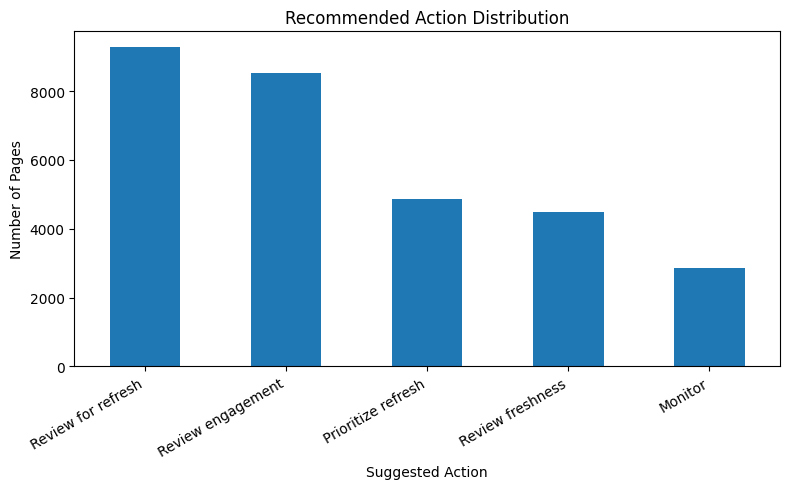

In [ ]:
import matplotlib.pyplot as plt

action_counts = (
    score_df["suggested_action"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

action_counts.plot(kind="bar")

plt.title("Recommended Action Distribution")
plt.xlabel("Suggested Action")
plt.ylabel("Number of Pages")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

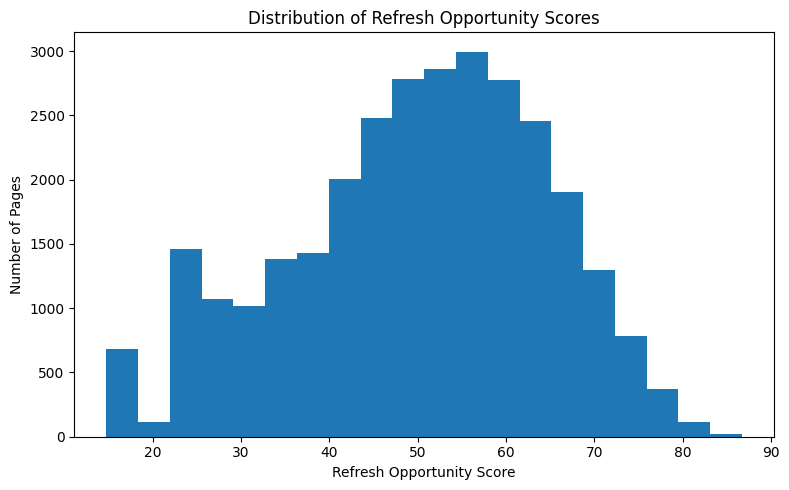

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    score_df["refresh_score"],
    bins=20
)

plt.title("Distribution of Refresh Opportunity Scores")
plt.xlabel("Refresh Opportunity Score")
plt.ylabel("Number of Pages")
plt.tight_layout()

plt.show()

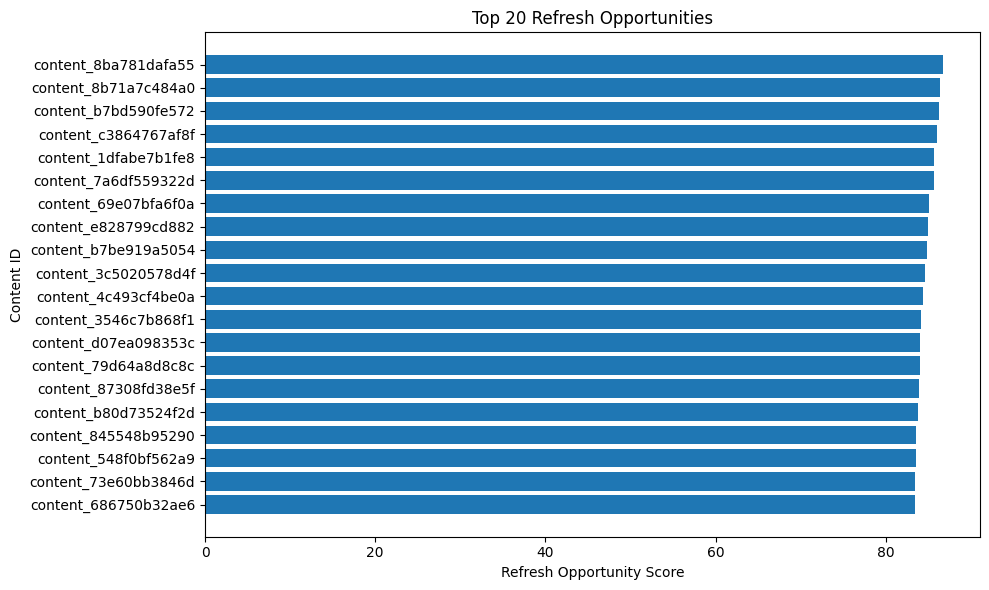

In [ ]:
top_20_chart = ranked_queue.head(20).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top_20_chart["content_id"].astype(str),
    top_20_chart["refresh_score"]
)

plt.title("Top 20 Refresh Opportunities")
plt.xlabel("Refresh Opportunity Score")
plt.ylabel("Content ID")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [ ]:
# Rebuild the action classification so every page receives exactly one action.

engagement_low_threshold = score_df["engagement_rate"].quantile(0.25)

def create_action_fixed(row):
    # Highest priority: strong decline + stale
    if (
        row["trend_pct"] <= -30
        and row["days_since_last_update"] >= 90
    ):
        return "Prioritize refresh"

    # Strong decline but not yet stale
    elif row["trend_pct"] <= -30:
        return "Review for refresh"

    # Stale content
    elif row["days_since_last_update"] >= 90:
        return "Review freshness"

    # Low engagement
    elif row["engagement_rate"] <= engagement_low_threshold:
        return "Review engagement"

    # Everything else
    else:
        return "Monitor"


score_df["suggested_action"] = score_df.apply(
    create_action_fixed,
    axis=1
)

# Rebuild ranked queue
ranked_queue = (
    score_df[
        [
            "content_id",
            "refresh_score",
            "suggested_action",
            "reason_codes",
            "trend_pct",
            "days_since_last_update",
            "impressions_90d",
            "search_volume",
            "engagement_rate"
        ]
    ]
    .sort_values("refresh_score", ascending=False)
    .reset_index(drop=True)
)

ranked_queue.index = ranked_queue.index + 1

# Verify every row has exactly one action
print("Action distribution:")
display(
    score_df["suggested_action"]
    .value_counts()
    .to_frame("count")
)

print("\nTotal classified pages:")
print(score_df["suggested_action"].notna().sum())

print("\nExpected total pages:")
print(len(score_df))

Action distribution:


,count
suggested_action,
Review for refresh,9272
Review engagement,8515
Prioritize refresh,4866
Review freshness,4479
Monitor,2868



Total classified pages:
30000

Expected total pages:
30000


In [ ]:
# Corrected capstone results summary

total_pages = len(score_df)

action_distribution = (
    score_df["suggested_action"]
    .value_counts()
)

top_20 = ranked_queue.head(20)

print("CORRECTED CAPSTONE RESULTS SUMMARY")
print("=================================")

print(f"Total pages analyzed: {total_pages}")

for action, count in action_distribution.items():
    percentage = count / total_pages * 100
    print(f"{action}: {count} ({percentage:.2f}%)")

print(
    f"Average refresh score: "
    f"{score_df['refresh_score'].mean():.2f}"
)

print(
    f"Top-20 average score: "
    f"{top_20['refresh_score'].mean():.2f}"
)

print(
    f"Top-20 average trend %: "
    f"{top_20['trend_pct'].mean():.2f}"
)

print(
    f"Top-20 average days since update: "
    f"{top_20['days_since_last_update'].mean():.2f}"
)

CORRECTED CAPSTONE RESULTS SUMMARY
Total pages analyzed: 30000
Review for refresh: 9272 (30.91%)
Review engagement: 8515 (28.38%)
Prioritize refresh: 4866 (16.22%)
Review freshness: 4479 (14.93%)
Monitor: 2868 (9.56%)
Average refresh score: 50.00
Top-20 average score: 84.71
Top-20 average trend %: -84.42
Top-20 average days since update: 100.95


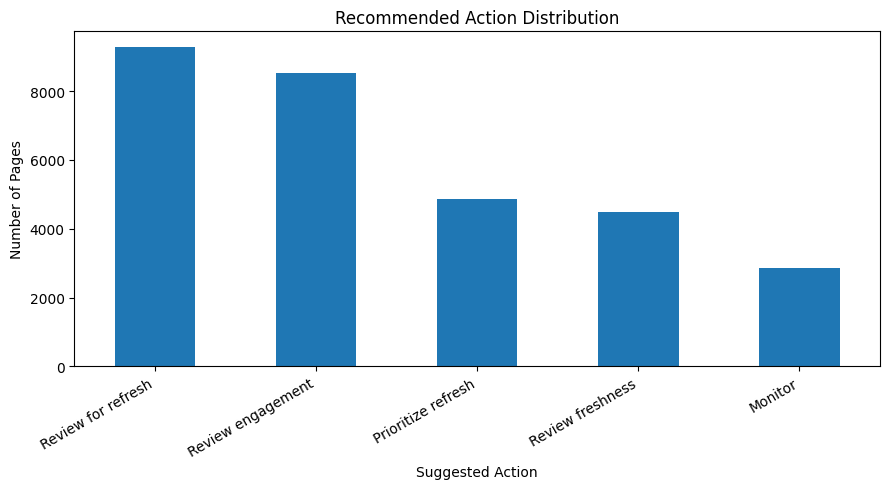

In [ ]:
import matplotlib.pyplot as plt

action_counts = (
    score_df["suggested_action"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

action_counts.plot(kind="bar")

plt.title("Recommended Action Distribution")
plt.xlabel("Suggested Action")
plt.ylabel("Number of Pages")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

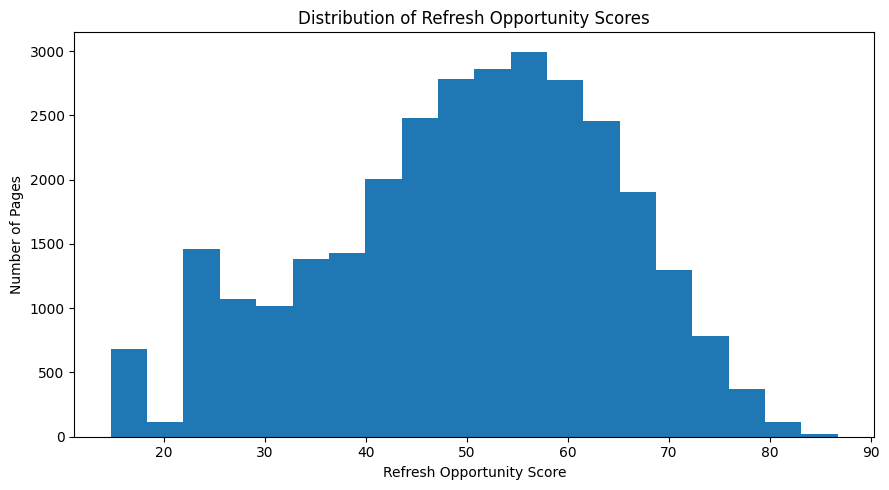

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    score_df["refresh_score"],
    bins=20
)

plt.title("Distribution of Refresh Opportunity Scores")
plt.xlabel("Refresh Opportunity Score")
plt.ylabel("Number of Pages")

plt.tight_layout()
plt.show()

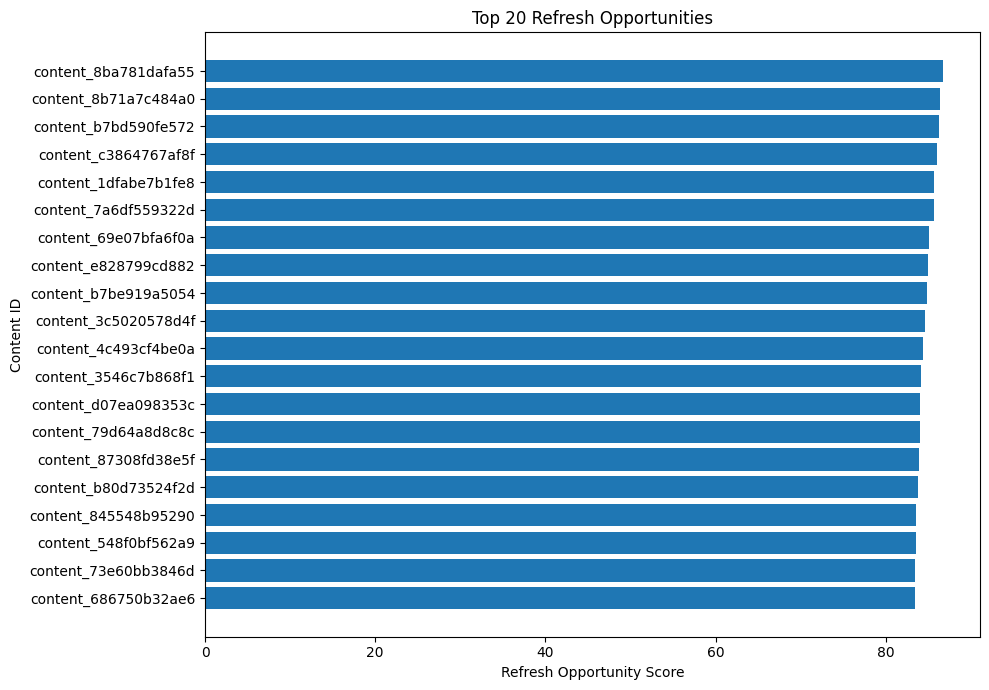

In [ ]:
top_20_chart = ranked_queue.head(20).copy()

plt.figure(figsize=(10, 7))

plt.barh(
    top_20_chart["content_id"].astype(str),
    top_20_chart["refresh_score"]
)

plt.title("Top 20 Refresh Opportunities")
plt.xlabel("Refresh Opportunity Score")
plt.ylabel("Content ID")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

The final scoring engine analyzed all 30,000 pages in the dataset and assigned each page one recommended action.

| Recommended action | Pages | Percentage |
|---|---:|---:|
| Review for refresh | 9,272 | 30.91% |
| Review engagement | 8,515 | 28.38% |
| Prioritize refresh | 4,866 | 16.22% |
| Review freshness | 4,479 | 14.93% |
| Monitor | 2,868 | 9.56% |

The average refresh opportunity score across all pages was **50.00**, while the top 20 pages had an average score of **84.71**.

The top 20 pages also showed an average observed trend of **−84.42%** and had been unchanged for an average of **100.95 days**.

These results indicate that the highest-ranked pages were characterized by a combination of strong observed decline, relatively high visibility or demand, and freshness or engagement concerns.

The results should be interpreted as prioritization evidence rather than proof that refreshing a page will cause performance to improve.

In [ ]:
results_summary = pd.DataFrame({
    "Recommended action": [
        "Review for refresh",
        "Review engagement",
        "Prioritize refresh",
        "Review freshness",
        "Monitor"
    ],
    "Pages": [
        9272,
        8515,
        4866,
        4479,
        2868
    ],
    "Percentage": [
        30.91,
        28.38,
        16.22,
        14.93,
        9.56
    ]
})

display(results_summary)

,Recommended action,Pages,Percentage
0,Review for refresh,9272,30.91
1,Review engagement,8515,28.38
2,Prioritize refresh,4866,16.22
3,Review freshness,4479,14.93
4,Monitor,2868,9.56


## 5. Limitations

*What this work cannot claim.*

### Limitations and honest framing

This analysis has several important limitations.

**1. Snapshot limitation**

The available dataset is treated as an observed snapshot. It does not provide a clean experimental before-and-after design for measuring the effect of a content refresh.

**2. No causal claim**

A high refresh score does not mean that refreshing a page will cause rankings, impressions, clicks, or engagement to increase.

**3. No Google algorithm claim**

The analysis does not identify or prove Google's ranking algorithm or any individual ranking factor.

**4. Proxy target**

The refresh opportunity label is constructed from observed signals. It represents an operational definition of review opportunity rather than a ground-truth outcome.

**5. Leakage risk**

An initial machine-learning experiment produced perfect scores. This was treated as a warning sign rather than a successful model because the target construction and available features could expose information related to the target.

**6. Missing values**

Some source variables contain missing values. Cleaning decisions can change the population available for individual modeling experiments.

**7. Generalization**

The results describe the analyzed FlyRank internship dataset and should not automatically be generalized to every website, industry, or search environment.

### Honest interpretation

The strongest claim supported by this work is:

> The scoring framework provides a repeatable, transparent way to prioritize pages for human review using observed search-performance, demand, freshness, and engagement signals.

The framework is therefore **decision-support**, not a guarantee of future performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

The scoring engine produces an actionable review queue rather than treating all pages equally.

#### 1. Prioritize pages with strong observed decline

Pages showing substantial negative movement should be reviewed first when they also have meaningful visibility or demand.

The top 20 opportunities had an average observed trend of **−84.42%**, indicating that decline was a major characteristic of the highest-ranked pages.

#### 2. Review stale high-opportunity pages

Pages that have not been updated for a long period and simultaneously show declining performance should receive earlier human review.

The top 20 pages had an average of **100.95 days since their last update**.

#### 3. Protect high-visibility content

A declining page with substantial impressions represents a larger review opportunity than a page with little observed visibility.

Reviewers should therefore consider visibility when deciding which pages to investigate first.

#### 4. Investigate engagement weaknesses

Pages with weak observed engagement should be reviewed for content usefulness, structure, relevance, and user experience.

The score identifies these pages for investigation; it does not determine the exact cause of weak engagement.

#### 5. Use the ranked queue as a review workflow

The recommended workflow is:

**Rank → investigate → diagnose → choose action → refresh or monitor → measure future performance**

The scoring engine should be used to decide where human attention goes first, not as an automatic instruction to change every high-scoring page.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
# Display the main artifacts that should be used in the research paper.

print("Artifact 1: Recommended Action Distribution")
display(results_summary)

print("\nArtifact 2: Top 20 Refresh Opportunities")
display(ranked_queue.head(20))

print("\nArtifact 3: Capstone Summary")

capstone_summary = pd.DataFrame({
    "Metric": [
        "Total pages analyzed",
        "Review for refresh",
        "Review engagement",
        "Prioritize refresh",
        "Review freshness",
        "Monitor",
        "Average refresh score",
        "Top-20 average score",
        "Top-20 average trend %",
        "Top-20 average days since update"
    ],
    "Value": [
        30000,
        9272,
        8515,
        4866,
        4479,
        2868,
        50.00,
        84.71,
        -84.42,
        100.95
    ]
})

display(capstone_summary)

Artifact 1: Recommended Action Distribution


,Recommended action,Pages,Percentage
0,Review for refresh,9272,30.91
1,Review engagement,8515,28.38
2,Prioritize refresh,4866,16.22
3,Review freshness,4479,14.93
4,Monitor,2868,9.56



Artifact 2: Top 20 Refresh Opportunities


,content_id,refresh_score,suggested_action,reason_codes,trend_pct,days_since_last_update,impressions_90d,search_volume,engagement_rate
1,content_8ba781dafa55,86.74,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-85.6,104,16156,2900.0,0.00
2,content_8b71a7c484a0,86.34,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-91.3,104,22661,90.0,1.23
3,content_b7bd590fe572,86.21,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-86.5,104,12331,590.0,0.00
4,content_c3864767af8f,86.03,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-92.0,104,8626,320.0,4.17
5,content_1dfabe7b1fe8,85.69,Prioritize refresh,"strong_decline, stale, high_visibility",-100.0,106,9582,10.0,2.50
6,content_7a6df559322d,85.64,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-94.7,104,43650,30.0,11.59
7,content_69e07bfa6f0a,85.14,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-91.0,104,4618,880.0,0.00
8,content_e828799cd882,84.98,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-78.6,104,13813,480.0,0.00
9,content_b7be919a5054,84.79,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-78.1,104,13711,390.0,0.00
10,content_3c5020578d4f,84.59,Prioritize refresh,"strong_decline, stale, high_visibility, high_d...",-80.9,104,21898,70.0,0.00



Artifact 3: Capstone Summary


,Metric,Value
0,Total pages analyzed,30000.00
1,Review for refresh,9272.00
2,Review engagement,8515.00
3,Prioritize refresh,4866.00
4,Review freshness,4479.00
5,Monitor,2868.00
6,Average refresh score,50.00
7,Top-20 average score,84.71
8,Top-20 average trend %,-84.42
9,Top-20 average days since update,100.95


## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

The analysis was completed as part of the FlyRank ML Internship and uses the anonymized search/content-performance data provided for the internship.

Data source: FlyRank.

https://flyrank.ai

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.